# Đánh giá chung VLM-RAG trong 1 file

Notebook này gom phần đánh giá chính vào **một file duy nhất**.  
Chạy từ trên xuống dưới để load model, build RAG index, sinh câu trả lời và xuất bảng đánh giá tổng hợp.

Các nhóm đánh giá chính:

| Nhóm đánh giá | Chỉ số chính |
|---|---|
| Nhận diện ảnh | Accuracy, Macro-F1, JSON Parse Rate, Confusion Matrix |
| Không chắc chắn / triage | Uncertainty Accuracy, Triage Accuracy |
| Truy hồi RAG | Hit@K, Recall@K, MRR |
| Trả lời QA | ROUGE-L, Token-F1 |
| Hiệu năng | Latency, VRAM, tokens/s |

Kết quả sẽ được lưu vào `/kaggle/working/eval_outputs`.


In [1]:
!pip install -q -U git+https://github.com/huggingface/transformers
!pip install -q -U accelerate peft bitsandbytes qwen-vl-utils sentencepiece scikit-learn
!pip install -q "pillow<12.0,>=10.0"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 2.9 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 29.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 2.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 10.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 26.5 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 67.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 39.3 MB/s eta 0:00:0000:01:00:01


In [2]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch

from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
    BitsAndBytesConfig,
)

from peft import PeftModel
from qwen_vl_utils import process_vision_info

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


SEED = 42
random.seed(SEED)
np.random.seed(SEED)

MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"
INPUT_ROOT = Path("/kaggle/input")

print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM GB:", torch.cuda.get_device_properties(0).total_memory / 1024**3)

print("INPUT_ROOT:", INPUT_ROOT)
print("INPUT_ROOT exists:", INPUT_ROOT.exists())

CUDA: True
GPU: Tesla T4
VRAM GB: 14.56317138671875
INPUT_ROOT: /kaggle/input
INPUT_ROOT exists: True


In [3]:
# Tìm adapter_model.safetensors trong toàn bộ /kaggle/input
adapter_files = list(INPUT_ROOT.rglob("adapter_model.safetensors"))

assert len(adapter_files) > 0, (
    "Không tìm thấy adapter_model.safetensors. "
    "Bạn cần Add Input dataset chứa LoRA adapter đã train."
)

ADAPTER_DIR = adapter_files[0].parent

print("ADAPTER_DIR:", ADAPTER_DIR)
print("\nFiles in adapter dir:")
for p in sorted(ADAPTER_DIR.iterdir()):
    print("-", p.name)


# Tìm file RAG và QA
rag_files = list(INPUT_ROOT.rglob("all_crops_rag_knowledge_standard_core.csv"))
qa_files = list(INPUT_ROOT.rglob("all_crops_spcqa_v4_similarity_safe_clean_merged.csv"))

assert len(rag_files) > 0, "Không tìm thấy all_crops_rag_knowledge_standard_core.csv"
assert len(qa_files) > 0, "Không tìm thấy all_crops_spcqa_v4_similarity_safe_clean_merged.csv"

RAG_CSV = rag_files[0]
QA_CSV = qa_files[0]
DATA_ROOT = RAG_CSV.parent

print("\nDATA_ROOT:", DATA_ROOT)
print("RAG_CSV:", RAG_CSV)
print("QA_CSV:", QA_CSV)

ADAPTER_DIR: /kaggle/input/datasets/hoanggiabao3105/qwen25-vl-3b-agri-lora-adapter

Files in adapter dir:
- README.md
- adapter_config.json
- adapter_model.safetensors
- chat_template.jinja
- processor_config.json
- tokenizer.json
- tokenizer_config.json
- train_info.json

DATA_ROOT: /kaggle/input/datasets/hoanggiabao3105/dataset
RAG_CSV: /kaggle/input/datasets/hoanggiabao3105/dataset/all_crops_rag_knowledge_standard_core.csv
QA_CSV: /kaggle/input/datasets/hoanggiabao3105/dataset/all_crops_spcqa_v4_similarity_safe_clean_merged.csv


In [4]:
adapter_config_path = ADAPTER_DIR / "adapter_config.json"
train_info_path = ADAPTER_DIR / "train_info.json"

with open(adapter_config_path, "r", encoding="utf-8") as f:
    adapter_config = json.load(f)

print("Adapter config:")
print(json.dumps(adapter_config, ensure_ascii=False, indent=2)[:3000])

if train_info_path.exists():
    with open(train_info_path, "r", encoding="utf-8") as f:
        train_info = json.load(f)

    print("\nTrain info:")
    print(json.dumps(train_info, ensure_ascii=False, indent=2))
else:
    print("\nKhông tìm thấy train_info.json, không sao.")

Adapter config:
{
  "alora_invocation_tokens": null,
  "alpha_pattern": {},
  "arrow_config": null,
  "auto_mapping": null,
  "base_model_name_or_path": "Qwen/Qwen2.5-VL-3B-Instruct",
  "bias": "none",
  "corda_config": null,
  "ensure_weight_tying": false,
  "eva_config": null,
  "exclude_modules": null,
  "fan_in_fan_out": false,
  "inference_mode": true,
  "init_lora_weights": true,
  "layer_replication": null,
  "layers_pattern": null,
  "layers_to_transform": null,
  "loftq_config": {},
  "lora_alpha": 32,
  "lora_bias": false,
  "lora_dropout": 0.05,
  "lora_ga_config": null,
  "megatron_config": null,
  "megatron_core": "megatron.core",
  "modules_to_save": null,
  "peft_type": "LORA",
  "peft_version": "0.19.1",
  "qalora_group_size": 16,
  "r": 16,
  "rank_pattern": {},
  "revision": null,
  "target_modules": [
    "gate_proj",
    "q_proj",
    "v_proj",
    "up_proj",
    "k_proj",
    "down_proj",
    "o_proj"
  ],
  "target_parameters": null,
  "task_type": "CAUSAL_LM",
  

In [5]:
MIN_PIXELS = 256 * 28 * 28
MAX_PIXELS = 512 * 28 * 28

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    min_pixels=MIN_PIXELS,
    max_pixels=MAX_PIXELS,
    trust_remote_code=True,
    use_fast=False,
)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

base_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)

model = PeftModel.from_pretrained(
    base_model,
    ADAPTER_DIR,
    is_trainable=False,
)

model.eval()

print("Base Qwen2.5-VL-3B + LoRA adapter loaded successfully.")

preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Base Qwen2.5-VL-3B + LoRA adapter loaded successfully.


In [6]:
SYSTEM_PROMPT = (
    "Bạn là mô hình thị giác-ngôn ngữ cho nông nghiệp. "
    "Nhiệm vụ của bạn là quan sát ảnh lá cây và trích xuất thông tin bệnh cây. "
    "Chỉ trả về JSON hợp lệ, không giải thích thêm."
)


def build_vlm_prompt(user_question):
    return f"""
Câu hỏi của người dùng:
{user_question}

Hãy quan sát ảnh và trả về JSON với đúng các trường sau:
- crop
- plant_part
- canonical_label
- condition_group
- visible_symptoms
- lesion_location
- symptom_pattern
- severity_level
- confidence_level
- triage_level
- image_quality

Yêu cầu:
- Chỉ trả về JSON.
- Không viết đoạn tư vấn xử lý bệnh.
- Không thêm phần giải thích bên ngoài JSON.
""".strip()


@torch.no_grad()
def vlm_predict_json(image_path, user_question="Lá cây này bị bệnh gì?", max_new_tokens=256):
    image_path = str(image_path)

    messages = [
        {
            "role": "system",
            "content": SYSTEM_PROMPT,
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image_path,
                },
                {
                    "type": "text",
                    "text": build_vlm_prompt(user_question),
                },
            ],
        },
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    ).to(model.device)

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        temperature=0.0,
    )

    generated_ids_trimmed = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(inputs.input_ids, generated_ids)
    ]

    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]

    return output_text.strip()


def extract_json_from_text(text):
    text = str(text).strip()

    start = text.find("{")
    end = text.rfind("}")

    if start == -1 or end == -1 or end <= start:
        return None

    json_str = text[start:end + 1]

    try:
        return json.loads(json_str)
    except Exception as e:
        print("JSON parse error:", e)
        print("Raw JSON string:")
        print(json_str)
        return None

In [7]:
def show_vlm_prediction(image_path, question="Lá cây này bị bệnh gì?"):
    image_path = str(image_path)

    img = Image.open(image_path).convert("RGB")

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    print("Image path:", image_path)
    print("Question:", question)

    pred_text = vlm_predict_json(image_path, question)
    pred_json = extract_json_from_text(pred_text)

    print("\n===== RAW VLM OUTPUT =====")
    print(pred_text)

    print("\n===== PARSED JSON =====")
    print(json.dumps(pred_json, ensure_ascii=False, indent=2))

    return pred_text, pred_json

In [8]:
rag_df = pd.read_csv(RAG_CSV)
qa_df = pd.read_csv(QA_CSV)

print("RAG shape:", rag_df.shape)
print("QA shape:", qa_df.shape)

print("\nRAG columns:")
print(rag_df.columns.tolist())

print("\nQA columns:")
print(qa_df.columns.tolist())

RAG shape: (239, 21)
QA shape: (125120, 22)

RAG columns:
['knowledge_id', 'row_type', 'crop', 'canonical_label', 'condition_group', 'scope_label', 'applies_to', 'plant_part', 'symptom_pattern', 'knowledge_type', 'knowledge_text', 'confusable_with', 'differential_reasoning', 'recommended_action', 'avoid_action', 'confidence_rule', 'triage_rule', 'source_name', 'source_url', 'evidence_excerpt', 'reliability_level']

QA columns:
['sample_id', 'image_id', 'image_path_masked', 'image_real_path', 'crop', 'canonical_label', 'condition_group', 'dataset_split', 'question_type', 'question', 'visible_symptoms', 'lesion_location', 'symptom_pattern', 'severity_level', 'image_quality', 'confidence_level', 'triage_level', 'label_mentioned_in_question', 'input_no_label', 'input_with_label', 'target_answer', 'linked_knowledge_ids']


In [9]:
def safe_text(x):
    if pd.isna(x):
        return ""
    return str(x).strip()


def join_non_empty(parts):
    return "\n".join([p for p in parts if p and str(p).strip()])


def combine_rag_row(row):
    fields = [
        "knowledge_id",
        "row_type",
        "crop",
        "canonical_label",
        "condition_group",
        "scope_label",
        "applies_to",
        "plant_part",
        "symptom_pattern",
        "knowledge_type",
        "knowledge_text",
        "confusable_with",
        "differential_reasoning",
        "recommended_action",
        "avoid_action",
        "confidence_rule",
        "triage_rule",
        "source_name",
        "evidence_excerpt",
        "reliability_level",
    ]

    parts = []
    for col in fields:
        if col in row:
            val = safe_text(row[col])
            if val:
                parts.append(f"{col}: {val}")

    return join_non_empty(parts)


def combine_qa_row(row):
    fields = [
        "sample_id",
        "crop",
        "canonical_label",
        "condition_group",
        "question_type",
        "question",
        "visible_symptoms",
        "lesion_location",
        "symptom_pattern",
        "severity_level",
        "confidence_level",
        "triage_level",
        "input_no_label",
        "target_answer",
        "linked_knowledge_ids",
    ]

    parts = []
    for col in fields:
        if col in row:
            val = safe_text(row[col])
            if val:
                parts.append(f"{col}: {val}")

    return join_non_empty(parts)


rag_df = rag_df.copy()
qa_df = qa_df.copy()

rag_df["doc_text"] = rag_df.apply(combine_rag_row, axis=1)
qa_df["doc_text"] = qa_df.apply(combine_qa_row, axis=1)

display(rag_df[["knowledge_id", "crop", "canonical_label", "knowledge_type", "doc_text"]].head())
display(qa_df[["sample_id", "crop", "canonical_label", "question_type", "doc_text"]].head())

,knowledge_id,crop,canonical_label,knowledge_type,doc_text
0,K_HEALTHY_001,bí đỏ,khỏe,healthy_baseline,knowledge_id: K_HEALTHY_001\nrow_type: knowled...
1,K_POWDERY_001,bí đỏ,bệnh phấn trắng,symptom,knowledge_id: K_POWDERY_001\nrow_type: knowled...
2,K_POWDERY_002,bí đỏ,bệnh phấn trắng,differential,knowledge_id: K_POWDERY_002\nrow_type: rule\nc...
3,K_DOWNY_001,bí đỏ,bệnh sương mai,symptom,knowledge_id: K_DOWNY_001\nrow_type: knowledge...
4,K_DOWNY_002,bí đỏ,bệnh sương mai,uncertainty_rule,knowledge_id: K_DOWNY_002\nrow_type: rule\ncro...


,sample_id,crop,canonical_label,question_type,doc_text
0,TOMATOQA000001,cà chua,bệnh đốm vi khuẩn,identification,sample_id: TOMATOQA000001\ncrop: cà chua\ncano...
1,TOMATOQA000002,cà chua,bệnh đốm vi khuẩn,visual_evidence,sample_id: TOMATOQA000002\ncrop: cà chua\ncano...
2,TOMATOQA000003,cà chua,bệnh đốm vi khuẩn,general_consultation,sample_id: TOMATOQA000003\ncrop: cà chua\ncano...
3,TOMATOQA000004,cà chua,bệnh đốm vi khuẩn,initial_action,sample_id: TOMATOQA000004\ncrop: cà chua\ncano...
4,TOMATOQA000005,cà chua,bệnh đốm vi khuẩn,differential_diagnosis,sample_id: TOMATOQA000005\ncrop: cà chua\ncano...


In [10]:
rag_vectorizer = TfidfVectorizer(
    lowercase=True,
    max_features=30000,
    ngram_range=(1, 2)
)

rag_matrix = rag_vectorizer.fit_transform(
    rag_df["doc_text"].fillna("").tolist()
)

print("RAG matrix:", rag_matrix.shape)

RAG matrix: (239, 10241)


In [11]:
def build_query_from_vlm(vlm_json, user_question):
    if vlm_json is None:
        vlm_json = {}

    parts = [
        safe_text(user_question),
        safe_text(vlm_json.get("crop", "")),
        safe_text(vlm_json.get("plant_part", "")),
        safe_text(vlm_json.get("canonical_label", "")),
        safe_text(vlm_json.get("condition_group", "")),
        safe_text(vlm_json.get("visible_symptoms", "")),
        safe_text(vlm_json.get("lesion_location", "")),
        safe_text(vlm_json.get("symptom_pattern", "")),
        safe_text(vlm_json.get("severity_level", "")),
        safe_text(vlm_json.get("confidence_level", "")),
        safe_text(vlm_json.get("triage_level", "")),
        safe_text(vlm_json.get("image_quality", "")),
    ]

    return " ".join([p for p in parts if p])

In [12]:
def retrieve_rag_knowledge(vlm_json, user_question, top_k=8):
    query = build_query_from_vlm(vlm_json, user_question)

    query_vec = rag_vectorizer.transform([query])
    sims = cosine_similarity(query_vec, rag_matrix).flatten()

    result = rag_df.copy()
    result["semantic_score"] = sims
    result["boost"] = 0.0

    crop = safe_text(vlm_json.get("crop", "")) if vlm_json else ""
    label = safe_text(vlm_json.get("canonical_label", "")) if vlm_json else ""
    condition_group = safe_text(vlm_json.get("condition_group", "")) if vlm_json else ""

    if crop and "crop" in result.columns:
        result.loc[
            result["crop"].fillna("").astype(str).eq(crop),
            "boost"
        ] += 0.25

    if label and "canonical_label" in result.columns:
        result.loc[
            result["canonical_label"].fillna("").astype(str).eq(label),
            "boost"
        ] += 0.75

    if condition_group and "condition_group" in result.columns:
        result.loc[
            result["condition_group"].fillna("").astype(str).eq(condition_group),
            "boost"
        ] += 0.15

    if "knowledge_type" in result.columns:
        preferred_types = [
            "symptom",
            "symptom_stage",
            "severity",
            "management",
            "recommended_action",
            "avoid_action",
            "differential",
            "differential_diagnosis",
            "confidence_rule",
            "triage_rule",
            "followup",
        ]

        result.loc[
            result["knowledge_type"].fillna("").astype(str).isin(preferred_types),
            "boost"
        ] += 0.15

    if "scope_label" in result.columns:
        result.loc[
            result["scope_label"].fillna("").astype(str).str.lower().isin(
                ["global_rule", "rule_general", "multi_label", "all"]
            ),
            "boost"
        ] += 0.05

    result["final_score"] = result["semantic_score"] + result["boost"]
    result = result.sort_values("final_score", ascending=False)

    keep_cols = [
        "knowledge_id",
        "row_type",
        "crop",
        "canonical_label",
        "condition_group",
        "scope_label",
        "plant_part",
        "symptom_pattern",
        "knowledge_type",
        "knowledge_text",
        "confusable_with",
        "differential_reasoning",
        "recommended_action",
        "avoid_action",
        "confidence_rule",
        "triage_rule",
        "reliability_level",
        "final_score",
    ]

    keep_cols = [c for c in keep_cols if c in result.columns]

    return result[keep_cols].head(top_k).reset_index(drop=True)

In [13]:
def retrieve_similar_qa(vlm_json, user_question, top_k=5, max_candidates=20000):
    crop = safe_text(vlm_json.get("crop", "")) if vlm_json else ""
    label = safe_text(vlm_json.get("canonical_label", "")) if vlm_json else ""

    candidate = qa_df.copy()

    # Ưu tiên cùng crop
    if crop and "crop" in candidate.columns:
        crop_df = candidate[candidate["crop"].fillna("").astype(str).eq(crop)].copy()
        if len(crop_df) >= 20:
            candidate = crop_df

    # Ưu tiên cùng label
    if label and "canonical_label" in candidate.columns:
        label_df = candidate[candidate["canonical_label"].fillna("").astype(str).eq(label)].copy()
        if len(label_df) >= 20:
            candidate = label_df

    # Nếu candidate quá lớn thì sample để nhẹ
    if len(candidate) > max_candidates:
        candidate = candidate.sample(max_candidates, random_state=SEED).copy()

    query = build_query_from_vlm(vlm_json, user_question)

    qa_vectorizer = TfidfVectorizer(
        lowercase=True,
        max_features=30000,
        ngram_range=(1, 2)
    )

    qa_matrix = qa_vectorizer.fit_transform(candidate["doc_text"].fillna("").tolist())
    query_vec = qa_vectorizer.transform([query])

    sims = cosine_similarity(query_vec, qa_matrix).flatten()

    candidate = candidate.copy()
    candidate["semantic_score"] = sims
    candidate["boost"] = 0.0

    if crop and "crop" in candidate.columns:
        candidate.loc[
            candidate["crop"].fillna("").astype(str).eq(crop),
            "boost"
        ] += 0.2

    if label and "canonical_label" in candidate.columns:
        candidate.loc[
            candidate["canonical_label"].fillna("").astype(str).eq(label),
            "boost"
        ] += 0.5

    if "question_type" in candidate.columns:
        preferred_question_types = [
            "identification",
            "severity_assessment",
            "management",
            "treatment",
            "differential_diagnosis",
            "triage",
        ]

        candidate.loc[
            candidate["question_type"].fillna("").astype(str).isin(preferred_question_types),
            "boost"
        ] += 0.05

    candidate["final_score"] = candidate["semantic_score"] + candidate["boost"]
    candidate = candidate.sort_values("final_score", ascending=False)

    keep_cols = [
        "sample_id",
        "crop",
        "canonical_label",
        "condition_group",
        "question_type",
        "question",
        "visible_symptoms",
        "lesion_location",
        "symptom_pattern",
        "severity_level",
        "confidence_level",
        "triage_level",
        "target_answer",
        "linked_knowledge_ids",
        "final_score",
    ]

    keep_cols = [c for c in keep_cols if c in candidate.columns]

    return candidate[keep_cols].head(top_k).reset_index(drop=True)

In [14]:
def compact_display(df, max_len=160):
    temp = df.copy()

    for col in temp.columns:
        if temp[col].dtype == "object":
            temp[col] = temp[col].astype(str).str.slice(0, max_len)

    display(temp)


def print_rag_items(rag_items):
    for i, row in rag_items.iterrows():
        print("=" * 80)
        print(f"RAG {i + 1}")
        print("knowledge_id:", row.get("knowledge_id", ""))
        print("crop:", row.get("crop", ""))
        print("canonical_label:", row.get("canonical_label", ""))
        print("knowledge_type:", row.get("knowledge_type", ""))
        print("symptom_pattern:", row.get("symptom_pattern", ""))

        if safe_text(row.get("knowledge_text", "")):
            print("\nknowledge_text:")
            print(row.get("knowledge_text", ""))

        if safe_text(row.get("differential_reasoning", "")):
            print("\ndifferential_reasoning:")
            print(row.get("differential_reasoning", ""))

        if safe_text(row.get("recommended_action", "")):
            print("\nrecommended_action:")
            print(row.get("recommended_action", ""))

        if safe_text(row.get("avoid_action", "")):
            print("\navoid_action:")
            print(row.get("avoid_action", ""))


def print_qa_items(qa_items):
    for i, row in qa_items.iterrows():
        print("=" * 80)
        print(f"QA {i + 1}")
        print("sample_id:", row.get("sample_id", ""))
        print("crop:", row.get("crop", ""))
        print("canonical_label:", row.get("canonical_label", ""))
        print("question_type:", row.get("question_type", ""))

        if safe_text(row.get("question", "")):
            print("\nquestion:")
            print(row.get("question", ""))

        if safe_text(row.get("visible_symptoms", "")):
            print("\nvisible_symptoms:")
            print(row.get("visible_symptoms", ""))

        if safe_text(row.get("target_answer", "")):
            print("\ntarget_answer:")
            print(row.get("target_answer", ""))

In [15]:
def build_llm_context(vlm_json, rag_items, qa_items):
    lines = []

    lines.append("## KẾT QUẢ PHÂN TÍCH ẢNH TỪ VLM")
    lines.append(json.dumps(vlm_json, ensure_ascii=False, indent=2))

    lines.append("\n## KIẾN THỨC RAG LIÊN QUAN")
    for i, row in rag_items.iterrows():
        lines.append(f"\n### Knowledge {i + 1}")

        for col in [
            "knowledge_id",
            "crop",
            "canonical_label",
            "condition_group",
            "knowledge_type",
            "symptom_pattern",
            "knowledge_text",
            "differential_reasoning",
            "recommended_action",
            "avoid_action",
            "confidence_rule",
            "triage_rule",
            "reliability_level",
        ]:
            if col in row and safe_text(row[col]):
                lines.append(f"- {col}: {safe_text(row[col])}")

    lines.append("\n## QA TƯƠNG TỰ")
    for i, row in qa_items.iterrows():
        lines.append(f"\n### QA {i + 1}")

        for col in [
            "sample_id",
            "crop",
            "canonical_label",
            "question_type",
            "question",
            "visible_symptoms",
            "lesion_location",
            "symptom_pattern",
            "severity_level",
            "confidence_level",
            "triage_level",
            "target_answer",
            "linked_knowledge_ids",
        ]:
            if col in row and safe_text(row[col]):
                lines.append(f"- {col}: {safe_text(row[col])}")

    return "\n".join(lines)

In [16]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

all_images = [
    p for p in DATA_ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in IMG_EXTS
]

print("Total images found:", len(all_images))

print("\nMột vài ảnh mẫu:")
for p in all_images[:10]:
    print(p)

Total images found: 10260

Một vài ảnh mẫu:
/kaggle/input/datasets/hoanggiabao3105/dataset/Bi_do/Bi_do/Bacterial Leaf Spot/Bacterial Leaf Spot (124).jpg
/kaggle/input/datasets/hoanggiabao3105/dataset/Bi_do/Bi_do/Bacterial Leaf Spot/Bacterial Leaf Spot (180).jpg
/kaggle/input/datasets/hoanggiabao3105/dataset/Bi_do/Bi_do/Bacterial Leaf Spot/Bacterial Leaf Spot (322).jpg
/kaggle/input/datasets/hoanggiabao3105/dataset/Bi_do/Bi_do/Bacterial Leaf Spot/Bacterial Leaf Spot (257).jpg
/kaggle/input/datasets/hoanggiabao3105/dataset/Bi_do/Bi_do/Bacterial Leaf Spot/Bacterial Leaf Spot (84).jpg
/kaggle/input/datasets/hoanggiabao3105/dataset/Bi_do/Bi_do/Bacterial Leaf Spot/Bacterial Leaf Spot (245).jpg
/kaggle/input/datasets/hoanggiabao3105/dataset/Bi_do/Bi_do/Bacterial Leaf Spot/Bacterial Leaf Spot (370).jpg
/kaggle/input/datasets/hoanggiabao3105/dataset/Bi_do/Bi_do/Bacterial Leaf Spot/Bacterial Leaf Spot (104).jpg
/kaggle/input/datasets/hoanggiabao3105/dataset/Bi_do/Bi_do/Bacterial Leaf Spot/Bacter

In [17]:
def run_vlm_rag_pipeline(image_path, user_question, rag_top_k=8, qa_top_k=5):
    print("===== STEP 1: VLM ANALYSIS =====")
    pred_text, pred_json = show_vlm_prediction(
        image_path=image_path,
        question=user_question
    )

    print("\n===== STEP 2: RETRIEVE RAG KNOWLEDGE =====")
    rag_items = retrieve_rag_knowledge(
        vlm_json=pred_json,
        user_question=user_question,
        top_k=rag_top_k
    )

    compact_display(rag_items)

    print("\n===== STEP 3: RETRIEVE SIMILAR QA =====")
    qa_items = retrieve_similar_qa(
        vlm_json=pred_json,
        user_question=user_question,
        top_k=qa_top_k
    )

    compact_display(qa_items)

    print("\n===== RAG TEXT DETAIL =====")
    print_rag_items(rag_items)

    print("\n===== QA TEXT DETAIL =====")
    print_qa_items(qa_items)

    llm_context = build_llm_context(
        vlm_json=pred_json,
        rag_items=rag_items,
        qa_items=qa_items
    )

    print("\n===== LLM CONTEXT PREVIEW =====")
    print(llm_context[:7000])

    return {
        "image_path": str(image_path),
        "user_question": user_question,
        "vlm_raw_output": pred_text,
        "vlm_json": pred_json,
        "rag_items": rag_items,
        "qa_items": qa_items,
        "llm_context": llm_context,
    }

In [18]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

LLM_ID = "Qwen/Qwen2.5-3B-Instruct"

llm_tokenizer = AutoTokenizer.from_pretrained(
    LLM_ID,
    trust_remote_code=True
)

llm_bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

llm_model = AutoModelForCausalLM.from_pretrained(
    LLM_ID,
    quantization_config=llm_bnb_config,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

llm_model.eval()

print("LLM loaded:", LLM_ID)

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

LLM loaded: Qwen/Qwen2.5-3B-Instruct


In [19]:
def build_final_answer_prompt(user_question, llm_context):
    system_prompt = """
Bạn là chatbot tư vấn bệnh lá cây cho nông nghiệp.

Nhiệm vụ:
- Trả lời tự nhiên, dễ hiểu bằng tiếng Việt.
- Chỉ dùng thông tin trong CONTEXT.
- Không bịa thuốc, liều lượng, nguyên nhân hoặc cách xử lý ngoài CONTEXT.
- Nếu ảnh/chứng cứ chưa đủ chắc chắn, hãy nói là "nghiêng về" hoặc "cần kiểm tra thêm", không khẳng định tuyệt đối.
- Không cần trả lời theo khuôn cứng, nhưng nên nói rõ:
  dấu hiệu thấy được, bệnh/nguyên nhân nghi ngờ, mức độ tin cậy, nên làm gì, tránh làm gì.
""".strip()

    user_prompt = f"""
CÂU HỎI NGƯỜI DÙNG:
{user_question}

CONTEXT:
{llm_context}

Hãy trả lời người dùng một cách tự nhiên, ngắn gọn nhưng đủ ý.
""".strip()

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

    return messages

In [20]:
@torch.no_grad()
def generate_final_answer(user_question, llm_context, max_new_tokens=512):
    messages = build_final_answer_prompt(
        user_question=user_question,
        llm_context=llm_context
    )

    text = llm_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = llm_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=6000
    ).to(llm_model.device)

    outputs = llm_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.4,
        top_p=0.9,
        repetition_penalty=1.08
    )

    generated = outputs[0][inputs["input_ids"].shape[-1]:]

    answer = llm_tokenizer.decode(
        generated,
        skip_special_tokens=True
    )

    return answer.strip()

# Đánh giá mô hình / pipeline

Phần này bổ sung các chỉ số chính để đưa vào báo cáo:

| Nhóm đánh giá | Chỉ số | Mục đích |
|---|---|---|
| Nhận diện ảnh | Accuracy, Macro-F1, Confusion Matrix | Đo khả năng nhận diện bệnh/tình trạng từ ảnh |
| Không chắc chắn / triage | Uncertainty Accuracy, Triage Accuracy | Đo mức thận trọng và khả năng phân loại ưu tiên xử lý |
| Hiệu năng | Latency, VRAM, tokens/s | Đo khả năng triển khai thực tế |

Với notebook pipeline/chatbot sẽ có thêm đánh giá RAG và QA.

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Số mẫu đánh giá dùng được: 30
[1/30] label_true=bệnh phấn trắng | label_pred=bệnh phấn trắng | ok=True | 30.11s
[2/30] label_true=bệnh sương mai | label_pred=khỏe | ok=False | 25.49s
[3/30] label_true=thiếu đạm và magiê | label_pred=khỏe | ok=False | 25.23s
[4/30] label_true=bệnh khảm do virus | label_pred=khỏe | ok=False | 24.18s
[5/30] label_true=bệnh xoăn vàng lá do virus | label_pred=bệnh khảm do virus | ok=False | 23.23s
[6/30] label_true=bệnh đốm mục tiêu | label_pred=bệnh đốm vi khuẩn | ok=False | 24.34s
[7/30] label_true=bệnh chảy gôm thân | label_pred=bệnh chảy gôm thân | ok=True | 26.88s
[8/30] label_true=bệnh đốm lá | label_pred=khỏe | ok=False | 25.43s
[9/30] label_true=bệnh sương mai | label_pred=bệnh sương mai | ok=True | 28.74s
[10/30] label_true=thiếu đạm và magiê | label_pred=khỏe | ok=False | 25.26s
[11/30] label_true=bệnh thán thư | label_pred=bệnh sương mai | ok=False | 24.29s
[12/30] label_true=thiếu đạm và kali | label_pred=bệnh đốm lá | ok=False | 23.91s
[13/30] 

,Nhóm đánh giá,Chỉ số,Kết quả,Mục đích
0,Nhận diện ảnh,"Accuracy, Macro-F1, JSON Parse Rate",Acc=0.467; Macro-F1=0.278; JSON=1.000,Đo khả năng nhận diện bệnh/tình trạng từ ảnh
1,Không chắc chắn / triage,"Uncertainty Accuracy, Triage Accuracy",Uncertainty=0.800; Triage=0.533,Đo khả năng không quá tự tin khi sai và phân l...
2,Hiệu năng,"Latency, VRAM, tokens/s",Latency mean=25.54s; p95=29.44s; tokens/s=0.1;...,Đo khả năng triển khai thực tế


,n,json_parse_rate,label_accuracy,label_macro_f1,crop_accuracy,condition_group_accuracy,severity_accuracy,confidence_accuracy,triage_accuracy,uncertainty_accuracy,latency_mean_s,latency_p95_s,tokens_per_s,peak_vram_gb
0,30,1.0,0.466667,0.278314,1.0,0.5,0.366667,0.6,0.533333,0.8,25.5353,29.439115,0.078323,1.979604



===== Accuracy theo từng trường JSON =====


,field,accuracy
0,crop,1.000000
1,canonical_label,0.466667
2,condition_group,0.500000
3,severity_level,0.366667
4,confidence_level,0.600000
5,triage_level,0.533333
6,image_quality,0.966667



===== Classification report: canonical_label =====
                             precision    recall  f1-score   support

         benh chay gom than       0.60      1.00      0.75         3
          benh heo vi khuan       0.00      0.00      0.00         1
         benh kham do virus       0.00      0.00      0.00         1
         benh kham la virus       0.50      1.00      0.67         1
                benh moc la       0.00      0.00      0.00         1
            benh phan trang       1.00      1.00      1.00         2
             benh suong mai       0.50      0.33      0.40         3
              benh than thu       0.00      0.00      0.00         1
 benh xoan vang la do virus       0.00      0.00      0.00         1
                benh đom la       0.00      0.00      0.00         1
       benh đom la septoria       1.00      1.00      1.00         1
       benh đom la vi khuan       0.00      0.00      0.00         1
          benh đom muc tieu       0.00      0.00  

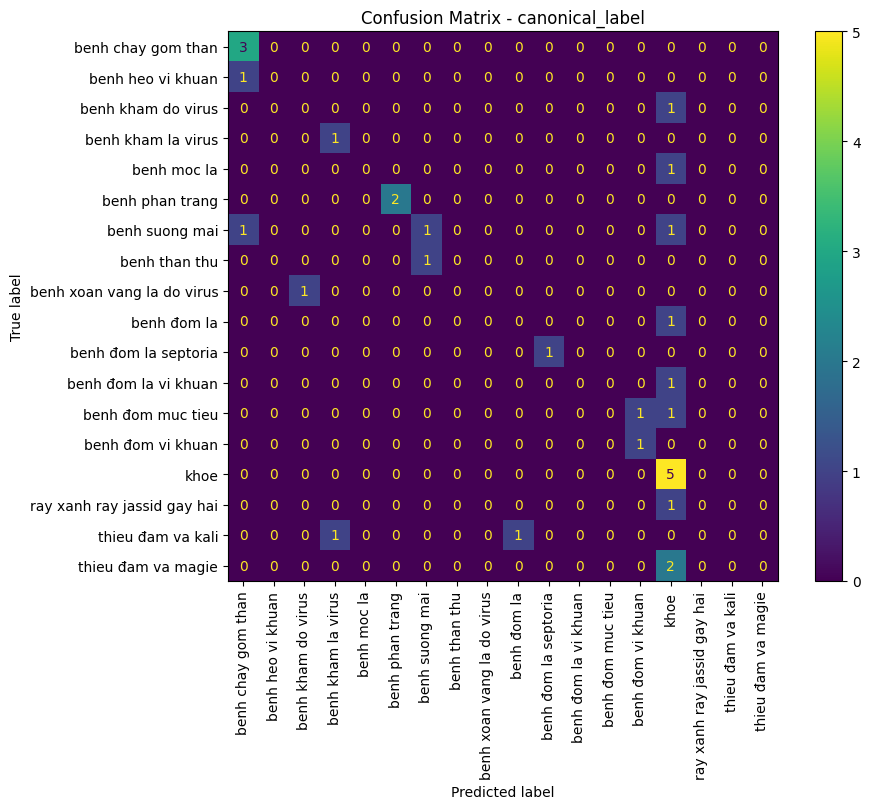


Đã lưu kết quả vào: /kaggle/working/eval_outputs


In [21]:

# ============================================================
# PHẦN ĐÁNH GIÁ CHÍNH: VLM nhận diện ảnh + uncertainty + hiệu năng
# ============================================================
# Chạy cell này sau khi model/adapter đã load xong.
# Có thể chỉnh số mẫu để chạy nhanh hơn trên Kaggle T4.
EVAL_N = 30                 # số ảnh dùng để đánh giá nhanh
EVAL_RANDOM_SEED = 42
EVAL_MAX_NEW_TOKENS = 256

import json
import re
import time
import unicodedata
from pathlib import Path
from collections import defaultdict
from pathlib import PurePosixPath

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


EVAL_FIELDS = [
    "crop",
    "canonical_label",
    "condition_group",
    "severity_level",
    "confidence_level",
    "triage_level",
    "image_quality",
]


def eval_safe_text(x):
    if x is None:
        return ""
    try:
        if pd.isna(x):
            return ""
    except Exception:
        pass
    return str(x).strip()


def eval_strip_accents(text):
    text = unicodedata.normalize("NFD", eval_safe_text(text))
    return "".join(ch for ch in text if unicodedata.category(ch) != "Mn")


def eval_norm_label(text):
    text = eval_strip_accents(text).lower()
    text = text.replace("_", " ").replace("-", " ")
    text = re.sub(r"[^a-z0-9à-ỹ\s]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    if text in {"nan", "none", "null"}:
        return ""
    return text


def eval_parse_json(text):
    # Ưu tiên hàm parse đã có trong notebook nếu tồn tại.
    fn = globals().get("extract_json_from_text")
    if callable(fn):
        try:
            parsed = fn(text)
            if isinstance(parsed, dict):
                return parsed
        except Exception:
            pass

    text = eval_safe_text(text).replace("```json", "```").replace("```JSON", "```").strip("` \n\t")
    start = text.find("{")
    end = text.rfind("}")
    if start == -1 or end == -1 or end <= start:
        return {}
    try:
        return json.loads(text[start:end + 1])
    except Exception:
        return {}


def eval_get_data_root():
    candidates = []
    for name in ["DATA_ROOT"]:
        if name in globals():
            try:
                candidates.append(Path(globals()[name]))
            except Exception:
                pass
    for name in ["QA_CSV", "RAG_CSV"]:
        if name in globals():
            try:
                candidates.append(Path(globals()[name]).parent)
            except Exception:
                pass
    candidates.append(Path("."))
    for p in candidates:
        if p.exists():
            return p
    return Path(".")


IMG_EXTS_EVAL = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def eval_clean_rel_parts(path_str):
    raw = eval_safe_text(path_str).replace("\\", "/")
    parts = [x for x in PurePosixPath(raw).parts if x not in ["/", ""]]
    if "dataset" in parts:
        idx = parts.index("dataset")
        parts = parts[idx + 1:]
    return parts


def eval_path_contains_crop(p, crop):
    crop = eval_norm_label(crop)
    crop_to_keys = {
        "bi do": ["Bi_do"],
        "ca chua": ["Ca_chua", "Ca_chua_filtered"],
        "dua leo": ["Dua_leo", "Dua_leo_filtered"],
        "kho qua muop dang": ["Kho_qua"],
        "kho qua": ["Kho_qua"],
    }
    keys = crop_to_keys.get(crop, [])
    return any(k in set(p.parts) for k in keys)


def eval_build_image_index(data_root=None):
    data_root = Path(data_root or eval_get_data_root())
    all_imgs = [
        p for p in data_root.rglob("*")
        if p.is_file() and p.suffix.lower() in IMG_EXTS_EVAL
    ]
    by_parent_file = defaultdict(list)
    by_filename = defaultdict(list)
    for p in all_imgs:
        by_parent_file[(p.parent.name.lower(), p.name.lower())].append(p)
        by_filename[p.name.lower()].append(p)
    return all_imgs, by_parent_file, by_filename


def eval_resolve_image_path(row, data_root=None, image_index=None):
    data_root = Path(data_root or eval_get_data_root())
    if image_index is None:
        image_index = eval_build_image_index(data_root)
    _, by_parent_file, by_filename = image_index

    raw_cols = ["image_path", "image_real_path", "image_path_masked"]
    crop = eval_safe_text(row.get("crop", "")) if hasattr(row, "get") else ""

    for col in raw_cols:
        raw = eval_safe_text(row.get(col, "")) if hasattr(row, "get") else ""
        if not raw:
            continue

        raw_path = Path(raw)
        if raw_path.exists():
            return str(raw_path)

        parts = eval_clean_rel_parts(raw)
        if not parts:
            continue

        candidates = [data_root.joinpath(*parts)]
        root = parts[0]

        if root == "Bi_do":
            candidates += [
                data_root.joinpath("Bi_do", "Bi_do", *parts[1:]),
                data_root.joinpath("Bi_do", *parts[1:]),
            ]
        elif root == "Ca_chua":
            candidates += [
                data_root.joinpath("Ca_chua_filtered", *parts[1:]),
                data_root.joinpath("Ca_chua", *parts[1:]),
            ]
        elif root == "Dua_leo":
            candidates += [
                data_root.joinpath("Dua_leo_filtered", *parts[1:]),
                data_root.joinpath("Dua_leo", *parts[1:]),
            ]
        elif root == "Kho_qua":
            candidates += [
                data_root.joinpath("Kho_qua", *parts[1:]),
                data_root.joinpath("Kho_qua", "Kho_qua", *parts[1:]),
            ]

        for p in candidates:
            if p.exists():
                return str(p)

        filename = parts[-1].lower()
        parent = parts[-2].lower() if len(parts) >= 2 else ""

        matches = by_parent_file.get((parent, filename), [])
        if not matches:
            matches = by_filename.get(filename, [])

        if len(matches) == 1:
            return str(matches[0])
        if len(matches) > 1:
            crop_matches = [p for p in matches if eval_path_contains_crop(p, crop)]
            return str(crop_matches[0] if crop_matches else matches[0])

    return None


def eval_make_truth_json_from_row(row):
    return {field: eval_safe_text(row.get(field, "")) for field in EVAL_FIELDS}


def eval_make_dataframe(max_rows=EVAL_N, seed=EVAL_RANDOM_SEED):
    if "val_df" in globals():
        base = globals()["val_df"].copy()
    elif "qa_df" in globals():
        base = globals()["qa_df"].copy()
    elif "QA_CSV" in globals() and Path(globals()["QA_CSV"]).exists():
        base = pd.read_csv(globals()["QA_CSV"])
    else:
        raise ValueError("Không tìm thấy val_df, qa_df hoặc QA_CSV để tạo tập đánh giá.")

    # Nếu chưa có image_path hợp lệ thì resolve từ image_real_path/image_path_masked.
    need_resolve = ("image_path" not in base.columns) or (base["image_path"].fillna("").astype(str).map(lambda x: not Path(x).exists()).mean() > 0.5)
    if need_resolve:
        data_root = eval_get_data_root()
        image_index = eval_build_image_index(data_root)
        base["image_path"] = base.apply(lambda r: eval_resolve_image_path(r, data_root=data_root, image_index=image_index), axis=1)

    base = base.dropna(subset=["image_path"]).copy()
    base = base[base["image_path"].astype(str).map(lambda x: Path(x).exists())].copy()

    if "canonical_label" in base.columns:
        base = base[base["canonical_label"].map(eval_safe_text) != ""].copy()

    base = base.drop_duplicates(subset=["image_path"]).reset_index(drop=True)

    if max_rows is not None and len(base) > max_rows:
        base = base.sample(max_rows, random_state=seed).reset_index(drop=True)

    print(f"Số mẫu đánh giá dùng được: {len(base)}")
    return base


def eval_call_vlm_predict(image_path, question, max_new_tokens=EVAL_MAX_NEW_TOKENS):
    fn = globals().get("vlm_predict_json")
    if not callable(fn):
        raise ValueError("Không tìm thấy hàm vlm_predict_json trong notebook.")

    try:
        return fn(image_path, user_question=question, max_new_tokens=max_new_tokens)
    except TypeError:
        try:
            return fn(image_path, user_question=question)
        except TypeError:
            try:
                return fn(image_path, question, max_new_tokens=max_new_tokens)
            except TypeError:
                return fn(image_path, question)


def eval_count_tokens(text):
    for name in ["processor", "vlm_processor", "llm_tokenizer"]:
        obj = globals().get(name)
        if obj is None:
            continue
        tok = getattr(obj, "tokenizer", obj)
        try:
            enc = tok(eval_safe_text(text), add_special_tokens=False)
            ids = enc["input_ids"] if isinstance(enc, dict) else enc
            if ids is not None:
                return len(ids)
        except Exception:
            pass
    return max(1, len(eval_safe_text(text).split()))


def eval_is_high_conf(x):
    n = eval_norm_label(x)
    return ("high" in n) or ("cao" in n) or ("rat cao" in n)


def eval_vlm_recognition(eval_df=None, max_rows=EVAL_N, question="Lá cây này bị bệnh gì?", show_confusion=True):
    eval_df = eval_make_dataframe(max_rows=max_rows) if eval_df is None else eval_df.copy()

    records = []
    total_out_tokens = 0

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            torch.cuda.reset_peak_memory_stats()
        except Exception:
            pass

    for i, row in eval_df.iterrows():
        image_path = row["image_path"]
        t0 = time.perf_counter()
        raw = eval_call_vlm_predict(image_path, question)
        latency = time.perf_counter() - t0

        pred_json = eval_parse_json(raw)
        total_out_tokens += eval_count_tokens(raw)

        rec = {
            "image_path": image_path,
            "raw_output": raw,
            "json_parse_ok": bool(pred_json),
            "latency_s": latency,
        }
        for field in EVAL_FIELDS:
            rec[f"true_{field}"] = eval_safe_text(row.get(field, ""))
            rec[f"pred_{field}"] = eval_safe_text(pred_json.get(field, "")) if isinstance(pred_json, dict) else ""
            rec[f"ok_{field}"] = eval_norm_label(rec[f"true_{field}"]) == eval_norm_label(rec[f"pred_{field}"])

        rec["label_correct"] = rec["ok_canonical_label"]
        rec["uncertainty_ok"] = rec["label_correct"] or (not eval_is_high_conf(rec["pred_confidence_level"]))
        records.append(rec)

        print(f"[{i+1}/{len(eval_df)}] label_true={rec['true_canonical_label']} | label_pred={rec['pred_canonical_label']} | ok={rec['label_correct']} | {latency:.2f}s")

    results_df = pd.DataFrame(records)
    if results_df.empty:
        raise ValueError("Không có kết quả đánh giá.")

    y_true = results_df["true_canonical_label"].map(eval_norm_label)
    y_pred = results_df["pred_canonical_label"].map(eval_norm_label)

    label_accuracy = accuracy_score(y_true, y_pred)
    label_macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    field_acc = {}
    for field in EVAL_FIELDS:
        mask = results_df[f"true_{field}"].map(eval_safe_text) != ""
        field_acc[field] = float(results_df.loc[mask, f"ok_{field}"].mean()) if mask.any() else np.nan

    peak_vram_gb = np.nan
    if torch.cuda.is_available():
        try:
            peak_vram_gb = torch.cuda.max_memory_allocated() / 1024**3
        except Exception:
            pass

    total_latency = float(results_df["latency_s"].sum())
    tokens_per_s = total_out_tokens / max(total_latency, 1e-9)

    summary = {
        "n": len(results_df),
        "json_parse_rate": float(results_df["json_parse_ok"].mean()),
        "label_accuracy": float(label_accuracy),
        "label_macro_f1": float(label_macro_f1),
        "crop_accuracy": field_acc.get("crop", np.nan),
        "condition_group_accuracy": field_acc.get("condition_group", np.nan),
        "severity_accuracy": field_acc.get("severity_level", np.nan),
        "confidence_accuracy": field_acc.get("confidence_level", np.nan),
        "triage_accuracy": field_acc.get("triage_level", np.nan),
        "uncertainty_accuracy": float(results_df["uncertainty_ok"].mean()),
        "latency_mean_s": float(results_df["latency_s"].mean()),
        "latency_p95_s": float(results_df["latency_s"].quantile(0.95)),
        "tokens_per_s": float(tokens_per_s),
        "peak_vram_gb": float(peak_vram_gb) if not pd.isna(peak_vram_gb) else np.nan,
    }

    print("\n===== BẢNG TÓM TẮT ĐÁNH GIÁ CHÍNH =====")
    main_report = pd.DataFrame([
        {
            "Nhóm đánh giá": "Nhận diện ảnh",
            "Chỉ số": "Accuracy, Macro-F1, JSON Parse Rate",
            "Kết quả": f"Acc={summary['label_accuracy']:.3f}; Macro-F1={summary['label_macro_f1']:.3f}; JSON={summary['json_parse_rate']:.3f}",
            "Mục đích": "Đo khả năng nhận diện bệnh/tình trạng từ ảnh",
        },
        {
            "Nhóm đánh giá": "Không chắc chắn / triage",
            "Chỉ số": "Uncertainty Accuracy, Triage Accuracy",
            "Kết quả": f"Uncertainty={summary['uncertainty_accuracy']:.3f}; Triage={summary['triage_accuracy']:.3f}",
            "Mục đích": "Đo khả năng không quá tự tin khi sai và phân loại mức ưu tiên xử lý",
        },
        {
            "Nhóm đánh giá": "Hiệu năng",
            "Chỉ số": "Latency, VRAM, tokens/s",
            "Kết quả": f"Latency mean={summary['latency_mean_s']:.2f}s; p95={summary['latency_p95_s']:.2f}s; tokens/s={summary['tokens_per_s']:.1f}; VRAM={summary['peak_vram_gb']:.2f}GB",
            "Mục đích": "Đo khả năng triển khai thực tế",
        },
    ])
    display(main_report)
    display(pd.DataFrame([summary]))

    print("\n===== Accuracy theo từng trường JSON =====")
    field_report = pd.DataFrame([
        {"field": k, "accuracy": v}
        for k, v in field_acc.items()
    ])
    display(field_report)

    print("\n===== Classification report: canonical_label =====")
    print(classification_report(y_true, y_pred, zero_division=0))

    if show_confusion:
        labels = sorted(set(y_true.tolist()) | set(y_pred.tolist()))
        if len(labels) <= 30:
            cm = confusion_matrix(y_true, y_pred, labels=labels)
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
            fig, ax = plt.subplots(figsize=(max(7, len(labels) * 0.55), max(6, len(labels) * 0.45)))
            disp.plot(ax=ax, xticks_rotation=90, values_format="d")
            plt.title("Confusion Matrix - canonical_label")
            plt.tight_layout()
            plt.show()
        else:
            print("Số lớp quá nhiều, hiển thị confusion matrix dạng bảng thay vì biểu đồ.")
            display(pd.crosstab(y_true, y_pred, rownames=["true"], colnames=["pred"]))

    out_dir = Path("/kaggle/working/eval_outputs") if Path("/kaggle/working").exists() else Path("./eval_outputs")
    out_dir.mkdir(parents=True, exist_ok=True)
    results_df.to_csv(out_dir / "vlm_recognition_eval_details.csv", index=False)
    pd.DataFrame([summary]).to_csv(out_dir / "vlm_recognition_eval_summary.csv", index=False)
    main_report.to_csv(out_dir / "main_eval_report_vlm.csv", index=False)

    print(f"\nĐã lưu kết quả vào: {out_dir}")
    return summary, results_df, main_report


# Chạy đánh giá nhanh.
# Tăng EVAL_N lên 100 hoặc toàn bộ val_df nếu muốn số liệu báo cáo chắc hơn.
vlm_eval_summary, vlm_eval_details, vlm_main_report = eval_vlm_recognition(max_rows=EVAL_N)


## Đánh giá RAG và câu trả lời QA

Các chỉ số bổ sung:

| Nhóm đánh giá | Chỉ số | Mục đích |
|---|---|---|
| Truy hồi RAG | Hit@K, Recall@K, MRR | Đo khả năng lấy đúng tri thức |
| Trả lời QA | ROUGE-L, Token-F1 | Đo độ tương đồng với đáp án mẫu |
| Hiệu năng trả lời | Latency, tokens/s | Đo tốc độ sinh câu trả lời cuối |


In [22]:

# ============================================================
# PHẦN ĐÁNH GIÁ RAG + CÂU TRẢ LỜI QA
# ============================================================
# Chạy sau cell đánh giá VLM ở trên và sau khi các hàm retrieve/generate đã được định nghĩa.
RAG_EVAL_N = 100
ANSWER_EVAL_N = 500        # sinh câu trả lời bằng LLM nên để nhỏ khi test nhanh
RAG_TOP_K = 5
QA_TOP_K = 3

import ast
import inspect
from collections import Counter


def eval_tokens(text):
    return re.findall(r"[a-z0-9à-ỹ]+", eval_norm_label(text))


def eval_token_f1(pred, ref):
    pred_toks = eval_tokens(pred)
    ref_toks = eval_tokens(ref)
    if not pred_toks and not ref_toks:
        return 1.0
    if not pred_toks or not ref_toks:
        return 0.0
    pred_counts = Counter(pred_toks)
    ref_counts = Counter(ref_toks)
    overlap = sum((pred_counts & ref_counts).values())
    if overlap == 0:
        return 0.0
    precision = overlap / len(pred_toks)
    recall = overlap / len(ref_toks)
    return 2 * precision * recall / (precision + recall)


def eval_rouge_l(pred, ref):
    x = eval_tokens(pred)
    y = eval_tokens(ref)
    if not x and not y:
        return 1.0
    if not x or not y:
        return 0.0

    # Giới hạn để tránh DP quá lớn nếu câu rất dài.
    x = x[:350]
    y = y[:350]
    dp = [0] * (len(y) + 1)
    for xi in x:
        prev = 0
        for j, yj in enumerate(y, start=1):
            tmp = dp[j]
            if xi == yj:
                dp[j] = prev + 1
            else:
                dp[j] = max(dp[j], dp[j - 1])
            prev = tmp
    lcs = dp[-1]
    prec = lcs / max(len(x), 1)
    rec = lcs / max(len(y), 1)
    if prec + rec == 0:
        return 0.0
    beta = 1.2
    return ((1 + beta**2) * prec * rec) / (rec + beta**2 * prec)


def eval_parse_linked_ids(x):
    text = eval_safe_text(x)
    if not text:
        return []
    # Thử parse dạng list JSON/Python trước.
    try:
        obj = ast.literal_eval(text)
        if isinstance(obj, (list, tuple, set)):
            return [eval_safe_text(v) for v in obj if eval_safe_text(v)]
        if isinstance(obj, str):
            return [obj]
    except Exception:
        pass

    # Fallback: tách theo dấu phân cách phổ biến.
    text = text.replace("|", ",").replace(";", ",")
    ids = [p.strip(" '\"\n\t") for p in text.split(",")]
    ids = [p for p in ids if p and eval_norm_label(p) not in {"nan", "none", "null"}]
    return ids


def eval_relevant_knowledge_ids_from_row(row):
    linked = eval_parse_linked_ids(row.get("linked_knowledge_ids", ""))
    if linked:
        return set(linked), "linked_knowledge_ids"

    # Nếu QA không có linked_knowledge_ids, dùng fallback cùng crop + canonical_label.
    if "rag_df" not in globals() or "knowledge_id" not in rag_df.columns:
        return set(), "none"

    mask = pd.Series(True, index=rag_df.index)
    crop = eval_norm_label(row.get("crop", ""))
    label = eval_norm_label(row.get("canonical_label", ""))

    if crop and "crop" in rag_df.columns:
        mask &= rag_df["crop"].map(eval_norm_label).eq(crop)
    if label and "canonical_label" in rag_df.columns:
        mask &= rag_df["canonical_label"].map(eval_norm_label).eq(label)

    ids = set(rag_df.loc[mask, "knowledge_id"].map(eval_safe_text))
    ids = {x for x in ids if x}
    return ids, "same_crop_label_fallback"


def eval_rag_retrieval(eval_df=None, max_rows=RAG_EVAL_N, top_k=RAG_TOP_K):
    if "retrieve_rag_knowledge" not in globals():
        raise ValueError("Không tìm thấy hàm retrieve_rag_knowledge.")

    eval_df = eval_make_dataframe(max_rows=max_rows) if eval_df is None else eval_df.copy()

    rows = []
    for i, row in eval_df.iterrows():
        gt_json = eval_make_truth_json_from_row(row)
        question = eval_safe_text(row.get("question", "")) or "Lá cây này bị bệnh gì và nên xử lý thế nào?"
        relevant_ids, relevant_source = eval_relevant_knowledge_ids_from_row(row)

        if not relevant_ids:
            continue

        t0 = time.perf_counter()
        rag_items = retrieve_rag_knowledge(gt_json, question, top_k=top_k)
        latency = time.perf_counter() - t0

        retrieved_ids = []
        if isinstance(rag_items, pd.DataFrame) and "knowledge_id" in rag_items.columns:
            retrieved_ids = rag_items["knowledge_id"].map(eval_safe_text).tolist()

        hit_rank = None
        for rank, kid in enumerate(retrieved_ids, start=1):
            if kid in relevant_ids:
                hit_rank = rank
                break

        top_ids = set(retrieved_ids[:top_k])
        rows.append({
            "sample_id": eval_safe_text(row.get("sample_id", "")),
            "crop": eval_safe_text(row.get("crop", "")),
            "canonical_label": eval_safe_text(row.get("canonical_label", "")),
            "relevant_source": relevant_source,
            "n_relevant": len(relevant_ids),
            f"hit@{top_k}": int(len(top_ids & relevant_ids) > 0),
            f"recall@{top_k}": len(top_ids & relevant_ids) / max(len(relevant_ids), 1),
            "mrr": 0.0 if hit_rank is None else 1.0 / hit_rank,
            "first_hit_rank": hit_rank,
            "retrieved_ids": retrieved_ids,
            "latency_s": latency,
        })

    details = pd.DataFrame(rows)
    if details.empty:
        raise ValueError("Không có mẫu RAG đủ ground-truth để đánh giá.")

    summary = {
        "n": len(details),
        f"hit@{top_k}": float(details[f"hit@{top_k}"].mean()),
        f"recall@{top_k}": float(details[f"recall@{top_k}"].mean()),
        "mrr": float(details["mrr"].mean()),
        "latency_mean_s": float(details["latency_s"].mean()),
    }

    report = pd.DataFrame([
        {
            "Nhóm đánh giá": "Truy hồi RAG",
            "Chỉ số": f"Hit Rate@{top_k}, Recall@{top_k}, MRR",
            "Kết quả": f"Hit@{top_k}={summary[f'hit@{top_k}']:.3f}; Recall@{top_k}={summary[f'recall@{top_k}']:.3f}; MRR={summary['mrr']:.3f}",
            "Mục đích": "Đo khả năng lấy đúng tri thức liên quan",
        }
    ])

    print("\n===== RAG RETRIEVAL EVALUATION =====")
    display(report)
    display(pd.DataFrame([summary]))
    display(details.head(20))

    out_dir = Path("/kaggle/working/eval_outputs") if Path("/kaggle/working").exists() else Path("./eval_outputs")
    out_dir.mkdir(parents=True, exist_ok=True)
    details.to_csv(out_dir / "rag_retrieval_eval_details.csv", index=False)
    pd.DataFrame([summary]).to_csv(out_dir / "rag_retrieval_eval_summary.csv", index=False)
    report.to_csv(out_dir / "main_eval_report_rag.csv", index=False)

    return summary, details, report


def eval_call_generate_final_answer(user_question, llm_context, vlm_json=None, rag_items=None, qa_items=None, max_new_tokens=256):
    fn = globals().get("generate_final_answer")
    if not callable(fn):
        raise ValueError("Không tìm thấy hàm generate_final_answer.")

    sig = inspect.signature(fn)
    kwargs = {}

    if "user_question" in sig.parameters:
        kwargs["user_question"] = user_question
    if "llm_context" in sig.parameters:
        kwargs["llm_context"] = llm_context
    if "history_context" in sig.parameters:
        kwargs["history_context"] = ""
    if "vlm_json" in sig.parameters:
        kwargs["vlm_json"] = vlm_json or {}
    if "rag_items" in sig.parameters:
        kwargs["rag_items"] = rag_items
    if "qa_items" in sig.parameters:
        kwargs["qa_items"] = qa_items
    if "chat_history" in sig.parameters:
        kwargs["chat_history"] = []
    if "max_new_tokens" in sig.parameters:
        kwargs["max_new_tokens"] = max_new_tokens

    if kwargs:
        return fn(**kwargs)

    # Fallback cho notebook cũ có signature generate_final_answer(user_question, llm_context, ...)
    return fn(user_question, llm_context)


def eval_answer_generation(eval_df=None, max_rows=ANSWER_EVAL_N, rag_top_k=RAG_TOP_K, qa_top_k=QA_TOP_K):
    if "build_llm_context" not in globals():
        raise ValueError("Không tìm thấy hàm build_llm_context.")
    if "generate_final_answer" not in globals():
        raise ValueError("Không tìm thấy hàm generate_final_answer.")
    if "target_answer" not in globals().get("qa_df", pd.DataFrame()).columns and eval_df is None:
        raise ValueError("QA CSV không có cột target_answer để đánh giá câu trả lời.")

    eval_df = eval_make_dataframe(max_rows=max_rows) if eval_df is None else eval_df.copy()
    if "target_answer" not in eval_df.columns:
        print("Không có target_answer trong eval_df, bỏ qua đánh giá câu trả lời.")
        return None, pd.DataFrame(), pd.DataFrame()

    eval_df = eval_df[eval_df["target_answer"].map(eval_safe_text) != ""].copy()
    if len(eval_df) > max_rows:
        eval_df = eval_df.sample(max_rows, random_state=EVAL_RANDOM_SEED).reset_index(drop=True)

    rows = []
    total_tokens = 0

    for i, row in eval_df.iterrows():
        gt_json = eval_make_truth_json_from_row(row)
        question = eval_safe_text(row.get("question", "")) or "Lá cây này bị bệnh gì và nên xử lý thế nào?"
        ref = eval_safe_text(row.get("target_answer", ""))

        rag_items = retrieve_rag_knowledge(gt_json, question, top_k=rag_top_k) if "retrieve_rag_knowledge" in globals() else pd.DataFrame()
        qa_items = retrieve_similar_qa(gt_json, question, top_k=qa_top_k) if "retrieve_similar_qa" in globals() else pd.DataFrame()
        llm_context = build_llm_context(gt_json, rag_items, qa_items)

        t0 = time.perf_counter()
        answer = eval_call_generate_final_answer(
            user_question=question,
            llm_context=llm_context,
            vlm_json=gt_json,
            rag_items=rag_items,
            qa_items=qa_items,
            max_new_tokens=256,
        )
        latency = time.perf_counter() - t0
        out_tokens = eval_count_tokens(answer)
        total_tokens += out_tokens


        rows.append({
            "sample_id": eval_safe_text(row.get("sample_id", "")),
            "question": question,
            "reference_answer": ref,
            "generated_answer": answer,
            "rouge_l": eval_rouge_l(answer, ref),
            "token_f1": eval_token_f1(answer, ref),
            "latency_s": latency,
            "tokens": out_tokens,
        })

        print(f"[{i+1}/{len(eval_df)}] ROUGE-L={rows[-1]['rouge_l']:.3f} | Token-F1={rows[-1]['token_f1']:.3f}")

    details = pd.DataFrame(rows)
    if details.empty:
        raise ValueError("Không có mẫu target_answer để đánh giá câu trả lời.")

    summary = {
        "n": len(details),
        "rouge_l": float(details["rouge_l"].mean()),
        "token_f1": float(details["token_f1"].mean()),
        "latency_mean_s": float(details["latency_s"].mean()),
        "tokens_per_s": float(total_tokens / max(details["latency_s"].sum(), 1e-9)),
    }

    report = pd.DataFrame([
        {
            "Nhóm đánh giá": "Trả lời QA",
            "Chỉ số": "ROUGE-L, Token-F1",
            "Kết quả": f"ROUGE-L={summary['rouge_l']:.3f}; Token-F1={summary['token_f1']:.3f}",
            "Mục đích": "Đo độ tương đồng với đáp án mẫu",
        },
        {
            "Nhóm đánh giá": "Hiệu năng trả lời",
            "Chỉ số": "Latency, tokens/s",
            "Kết quả": f"Latency mean={summary['latency_mean_s']:.2f}s; tokens/s={summary['tokens_per_s']:.1f}",
            "Mục đích": "Đo tốc độ sinh câu trả lời cuối",
        },
    ])

    print("\n===== QA ANSWER EVALUATION =====")
    display(report)
    display(pd.DataFrame([summary]))
    display(details[["sample_id", "rouge_l", "token_f1", "question", "generated_answer"]].head(10))

    out_dir = Path("/kaggle/working/eval_outputs") if Path("/kaggle/working").exists() else Path("./eval_outputs")
    out_dir.mkdir(parents=True, exist_ok=True)
    details.to_csv(out_dir / "qa_answer_eval_details.csv", index=False)
    pd.DataFrame([summary]).to_csv(out_dir / "qa_answer_eval_summary.csv", index=False)
    report.to_csv(out_dir / "main_eval_report_qa.csv", index=False)

    return summary, details, report


# Chạy các phần đánh giá còn lại.
rag_eval_summary, rag_eval_details, rag_main_report = eval_rag_retrieval(max_rows=RAG_EVAL_N, top_k=RAG_TOP_K)

answer_eval_summary, answer_eval_details, answer_main_report = eval_answer_generation(
    max_rows=ANSWER_EVAL_N,
    rag_top_k=RAG_TOP_K,
    qa_top_k=QA_TOP_K,
)

print("\n===== BẢNG TỔNG HỢP GIỐNG PHẦN TRÌNH BÀY BÁO CÁO =====")
reports = []
if "vlm_main_report" in globals():
    reports.append(vlm_main_report)
reports.append(rag_main_report)
if answer_main_report is not None and len(answer_main_report) > 0:
    reports.append(answer_main_report)

pipeline_main_report = pd.concat(reports, ignore_index=True)
display(pipeline_main_report)

out_dir = Path("/kaggle/working/eval_outputs") if Path("/kaggle/working").exists() else Path("./eval_outputs")
out_dir.mkdir(parents=True, exist_ok=True)
pipeline_main_report.to_csv(out_dir / "main_evaluation_report_all.csv", index=False)
print(f"Đã lưu bảng tổng hợp vào: {out_dir / 'main_evaluation_report_all.csv'}")


Số mẫu đánh giá dùng được: 100

===== RAG RETRIEVAL EVALUATION =====


,Nhóm đánh giá,Chỉ số,Kết quả,Mục đích
0,Truy hồi RAG,"Hit Rate@5, Recall@5, MRR",Hit@5=1.000; Recall@5=0.521; MRR=0.970,Đo khả năng lấy đúng tri thức liên quan


,n,hit@5,recall@5,mrr,latency_mean_s
0,100,1.0,0.521398,0.970333,0.008585


,sample_id,crop,canonical_label,relevant_source,n_relevant,hit@5,recall@5,mrr,first_hit_rank,retrieved_ids,latency_s
0,BIDO5CQA011053,bí đỏ,bệnh phấn trắng,linked_knowledge_ids,10,1,0.500000,1.0,1,"[K_POWDERY_002, K_DIFF_POWDERY_DUST_001, K_POW...",0.014438
1,BGQA000031,khổ qua/mướp đắng,bệnh sương mai,linked_knowledge_ids,7,1,0.428571,1.0,1,"[K_BGT_DOWNY_UMN_CUCURBIT_002, K_BGT_DOWNY_SYM...",0.009066
2,BGQA012691,khổ qua/mướp đắng,thiếu đạm và magiê,linked_knowledge_ids,7,1,0.571429,1.0,1,"[K_BGT_NMG_DEF_SYMPTOM_001, K_BGT_NMG_DEF_CONF...",0.008782
3,TOMATOQA028785,cà chua,bệnh khảm do virus,linked_knowledge_ids,8,1,0.625000,1.0,1,"[K_TOMATO_MOSAIC_VIRUS_DIFF_001, K_TOMATO_MOSA...",0.008539
4,TOMATOQA025177,cà chua,bệnh xoăn vàng lá do virus,linked_knowledge_ids,8,1,0.625000,1.0,1,"[K_TOMATO_YELLOW_LEAF_CURL_CONFIDENCE_001, K_T...",0.008521
5,TOMATOQA019393,cà chua,bệnh đốm mục tiêu,linked_knowledge_ids,8,1,0.625000,1.0,1,"[K_TOMATO_TARGET_SPOT_SYMPTOM_001, K_TOMATO_TA...",0.008746
6,CUCQA09403,dưa leo,bệnh chảy gôm thân,linked_knowledge_ids,12,1,0.416667,1.0,1,"[K_CUC_GUMMY_CONF_001, K_CUC_GUMMY_TRIAGE_001,...",0.008493
7,BGQA005233,khổ qua/mướp đắng,bệnh đốm lá,linked_knowledge_ids,6,1,0.666667,1.0,1,"[K_BGT_LEAFSPOT_SYMPTOM_001, K_BGT_LEAFSPOT_CO...",0.008849
8,BIDO5CQA004099,bí đỏ,bệnh sương mai,linked_knowledge_ids,13,1,0.307692,1.0,1,"[K_DOWNY_EARLY_001, K_DOWNY_SEVERE_001, K_DOWN...",0.008303
9,BGQA010753,khổ qua/mướp đắng,thiếu đạm và magiê,linked_knowledge_ids,7,1,0.571429,1.0,1,"[K_BGT_NMG_DEF_SYMPTOM_001, K_BGT_NMG_DEF_CONF...",0.008152


Số mẫu đánh giá dùng được: 500
[1/500] ROUGE-L=0.418 | Token-F1=0.500
[2/500] ROUGE-L=0.244 | Token-F1=0.422
[3/500] ROUGE-L=0.223 | Token-F1=0.444
[4/500] ROUGE-L=0.635 | Token-F1=0.703
[5/500] ROUGE-L=0.599 | Token-F1=0.692
[6/500] ROUGE-L=0.472 | Token-F1=0.589
[7/500] ROUGE-L=0.449 | Token-F1=0.583
[8/500] ROUGE-L=0.317 | Token-F1=0.454
[9/500] ROUGE-L=0.254 | Token-F1=0.443
[10/500] ROUGE-L=0.218 | Token-F1=0.387
[11/500] ROUGE-L=0.336 | Token-F1=0.528
[12/500] ROUGE-L=0.297 | Token-F1=0.481
[13/500] ROUGE-L=0.170 | Token-F1=0.389
[14/500] ROUGE-L=0.706 | Token-F1=0.732
[15/500] ROUGE-L=0.368 | Token-F1=0.425
[16/500] ROUGE-L=0.745 | Token-F1=0.742
[17/500] ROUGE-L=0.361 | Token-F1=0.517
[18/500] ROUGE-L=0.314 | Token-F1=0.490
[19/500] ROUGE-L=0.471 | Token-F1=0.569
[20/500] ROUGE-L=0.374 | Token-F1=0.460
[21/500] ROUGE-L=0.588 | Token-F1=0.674
[22/500] ROUGE-L=0.554 | Token-F1=0.675
[23/500] ROUGE-L=0.725 | Token-F1=0.780
[24/500] ROUGE-L=0.611 | Token-F1=0.650
[25/500] ROUGE-L=0

...

,n,rouge_l,token_f1,latency_mean_s,tokens_per_s
0,500,0.411579,0.529515,15.426549,0.129647


,sample_id,rouge_l,token_f1,question,generated_answer
0,BIDO5CQA011053,0.417675,0.500000,Dấu hiệu mức trung bình này có điểm gì giúp ph...,Mức độ trung bình này giúp bạn phân biệt với s...
1,BGQA000031,0.243857,0.421769,Lá cây này thấy rõ hơn ở một phần lá và vàng t...,"Theo ảnh bạn cung cấp, lá cây có dấu hiệu vàng..."
2,BGQA012691,0.222860,0.444444,Lá cây này vàng giữa gân và thiếu xanh nên ngh...,"Theo ảnh, lá cây bạn đang gặp phải tình trạng ..."
3,TOMATOQA028785,0.635074,0.702703,Lá cà chua có mảng khảm không đều như vậy có p...,"Theo kết quả phân tích ảnh, lá cà chua có dấu ..."
4,TOMATOQA025177,0.598983,0.691892,"Lá cà chua có lá nhỏ, quăn lên và vàng mép là ...","Theo phân tích ảnh, lá cà chua của bạn có thể ..."
5,TOMATOQA019393,0.471974,0.588832,Lá cà chua có đốm nâu dạng mục tiêu có đáng lo...,"Theo ảnh phân tích, lá cà chua của bạn có nhữn..."
6,CUCQA09403,0.449455,0.583333,"Nhìn ảnh này dưa chuột có vết cháy nâu khá rõ,...","Dựa trên hình ảnh bạn cung cấp, dưa chuột có d..."
7,BGQA005233,0.316919,0.453901,"Cây khổ qua có đốm cháy nhỏ, đây là bệnh đốm l...","Cây khổ qua có những đốm cháy nhỏ, đây có thể ..."
8,BIDO5CQA004099,0.253607,0.442748,"dựa trên vùng lá quan sát được, dấu hiệu này d...","Bên cạnh bệnh sương mai, dấu hiệu này cũng có ..."
9,BGQA010753,0.218286,0.387435,Cây khổ qua thấy rõ hơn ở một phần lá và vàng ...,"Theo kết quả phân tích ảnh, dấu hiệu vàng giữa..."



===== BẢNG TỔNG HỢP GIỐNG PHẦN TRÌNH BÀY BÁO CÁO =====


,Nhóm đánh giá,Chỉ số,Kết quả,Mục đích
0,Nhận diện ảnh,"Accuracy, Macro-F1, JSON Parse Rate",Acc=0.467; Macro-F1=0.278; JSON=1.000,Đo khả năng nhận diện bệnh/tình trạng từ ảnh
1,Không chắc chắn / triage,"Uncertainty Accuracy, Triage Accuracy",Uncertainty=0.800; Triage=0.533,Đo khả năng không quá tự tin khi sai và phân l...
2,Hiệu năng,"Latency, VRAM, tokens/s",Latency mean=25.54s; p95=29.44s; tokens/s=0.1;...,Đo khả năng triển khai thực tế
3,Truy hồi RAG,"Hit Rate@5, Recall@5, MRR",Hit@5=1.000; Recall@5=0.521; MRR=0.970,Đo khả năng lấy đúng tri thức liên quan
4,Trả lời QA,"ROUGE-L, Token-F1",ROUGE-L=0.412; Token-F1=0.530,Đo độ tương đồng với đáp án mẫu
5,Hiệu năng trả lời,"Latency, tokens/s",Latency mean=15.43s; tokens/s=0.1,Đo tốc độ sinh câu trả lời cuối


Đã lưu bảng tổng hợp vào: /kaggle/working/eval_outputs/main_evaluation_report_all.csv
